# Цель ноутбука 05 - проверить простые правила, получить первые метрики, понять насколько сложно отличать дубли без ML.

In [1]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.models.baseline import (
    add_baseline_scores,
    evaluate_baselines,
    predict_by_threshold,
    get_confusion_matrix_df,
)

In [2]:
# ============================================================
# LOAD TRAIN / VALID / TEST PAIRS
# ============================================================

train_pairs = pd.read_parquet("../data/processed/train_pairs.parquet")
valid_pairs = pd.read_parquet("../data/processed/valid_pairs.parquet")
test_pairs = pd.read_parquet("../data/processed/test_pairs.parquet")

print(f"Train: {len(train_pairs):,}")
print(f"Valid: {len(valid_pairs):,}")
print(f"Test:  {len(test_pairs):,}")

Train: 120,894
Valid: 15,306
Test:  14,812


In [3]:
# ============================================================
# ADD BASELINE SCORES
# ============================================================

train_scored = add_baseline_scores(train_pairs)
valid_scored = add_baseline_scores(valid_pairs)
test_scored = add_baseline_scores(test_pairs)

display(valid_scored.head())

,idx1,idx2,label,pair_type,name_similarity,record_id_1,party_public_id_1,party_name_1,name_latin_1,name_no_legal_1,...,company_public_id_2,company_name_norm_2,pair_left,pair_right,pair_key,entity_group,exact_match_score,fuzz_ratio,token_sort_ratio,token_set_ratio
0,377882,3719830,0,easy_negative_different_public_id,NaN,arm_rec_4fe15419df3e9e59ad50d3dd5938e533,arm_party_08c10e0c2e663101,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,արդյունաբերական ընկերություն բը,...,tjk_company_bc1fbea4c0dedd7a,муассисаи давлатии мактаби тахсилоти миёнаи ум...,377882,3719830,377882_3719830,arm_party_08c10e0c2e663101__tjk_party_f0b6b95b...,0,33.333333,33.333333,33.333333
1,3653522,3653523,1,positive_same_public_id,NaN,tjk_rec_98ea2d7d8d877c4ce8e57d768583410f,tjk_party_acc2166bccd51f12,Суфиев Шодимахмад Зикриёевич,sufiev shodimahmad zikrie evich,суфиев шодимахмад зикрие евич,...,tjk_company_8a576c6086e8988d,NaN,3653522,3653523,3653522_3653523,tjk_party_acc2166bccd51f12__tjk_party_acc2166b...,1,100.000000,100.000000,100.000000
2,3706326,3706327,1,positive_same_public_id,NaN,tjk_rec_d363d5f174acd778bf579bc5c6ea0398,tjk_party_8c8d2790fd412925,Юлдошева Нигора Рашидовна,yuldosheva nigora rashidovna,юлдошева нигора рашидовна,...,tjk_company_df145d867ddb68f6,муассисаи давлатии таълимии томактабии ширхорг...,3706326,3706327,3706326_3706327,tjk_party_8c8d2790fd412925__tjk_party_8c8d2790...,1,100.000000,100.000000,100.000000
3,3705372,3652140,0,easy_negative_different_public_id,NaN,tjk_rec_1af4f69ffc4c3f0e624a07b02adca9b1,tjk_party_fae117f8cb00629b,Урунов Алишер Кудратович,urunov alisher kudratovich,урунов алишер кудратович,...,tjk_company_2c26564dd555764f,ҷамъияти дорои масъулияти маҳдуди ободкор н,3652140,3705372,3652140_3705372,tjk_party_964309fa894ec90a__tjk_party_fae117f8...,0,46.153846,38.461538,38.461538
4,3675590,3732335,0,easy_negative_different_public_id,NaN,tjk_rec_328b6da762b9d98fd744c38cd398717e,tjk_party_39cc1dfe14560b87,Валиев Рахмон,valiev rahmon,валиев рахмон,...,tjk_company_e05f2be796c0c3fb,NaN,3675590,3732335,3675590_3732335,tjk_party_39cc1dfe14560b87__tjk_party_97fd765b...,0,31.578947,31.578947,31.578947


In [4]:
# ============================================================
# SCORE DISTRIBUTION ON VALID
# ============================================================

score_cols = [
    "exact_match_score",
    "fuzz_ratio",
    "token_sort_ratio",
    "token_set_ratio",
]

valid_scored[score_cols + ["label"]].describe()

,exact_match_score,fuzz_ratio,token_sort_ratio,token_set_ratio,label
count,15306.000000,15306.000000,15306.000000,15306.000000,15306.000000
mean,0.505488,69.590590,68.744612,68.765697,0.506860
std,0.499986,31.938973,32.540705,32.536316,0.499969
min,0.000000,6.896552,10.526316,10.526316,0.000000
25%,0.000000,36.363636,35.714286,35.714286,0.000000
50%,1.000000,100.000000,100.000000,100.000000,1.000000
75%,1.000000,100.000000,100.000000,100.000000,1.000000
max,1.000000,100.000000,100.000000,100.000000,1.000000


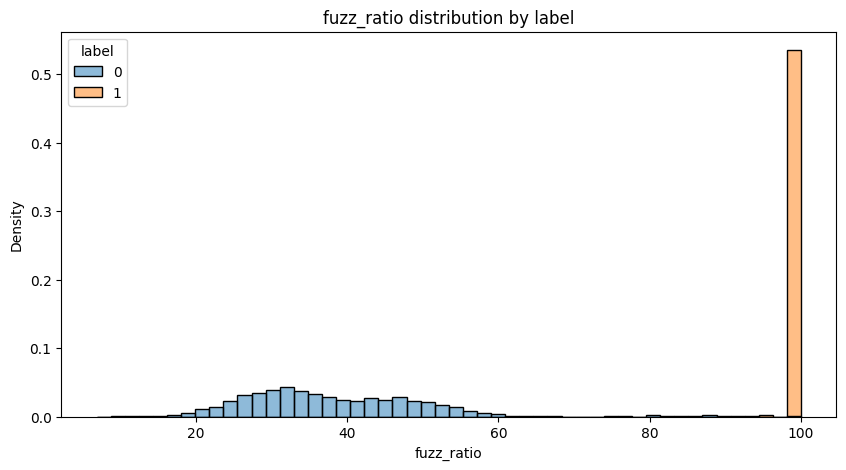

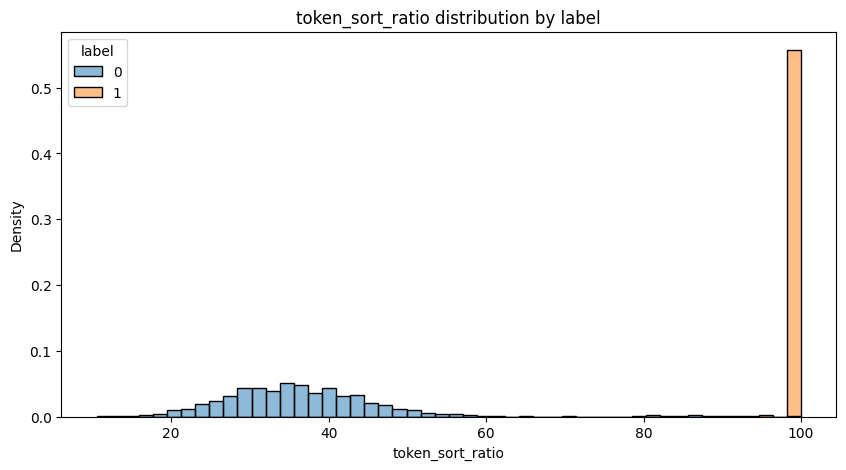

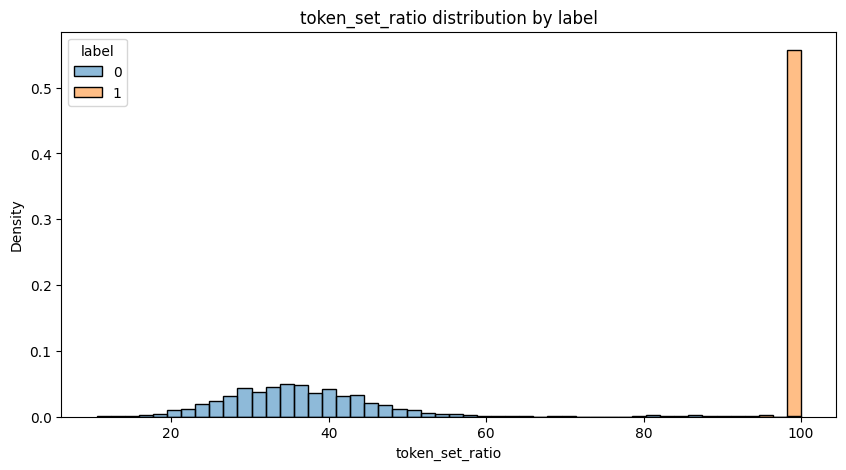

In [5]:
# ============================================================
# VISUALIZE SCORE DISTRIBUTIONS
# ============================================================

for col in [
    "fuzz_ratio",
    "token_sort_ratio",
    "token_set_ratio",
]:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=valid_scored,
        x=col,
        hue="label",
        bins=50,
        stat="density",
        common_norm=False,
    )

    plt.title(f"{col} distribution by label")
    plt.show()

In [6]:
# ============================================================
# EVALUATE BASELINES ON VALID
# ============================================================

thresholds = {
    "exact_match_score": [1],
    "fuzz_ratio": [70, 80, 85, 90, 95],
    "token_sort_ratio": [70, 80, 85, 90, 95],
    "token_set_ratio": [70, 80, 85, 90, 95],
}

valid_results = evaluate_baselines(
    valid_scored,
    thresholds=thresholds,
)

valid_results = valid_results.sort_values(
    "f1",
    ascending=False,
)

display(valid_results)

,method,threshold,accuracy,precision,recall,f1,roc_auc
5,fuzz_ratio,95,0.999543,0.999099,1.000000,0.999549,0.999865
10,token_sort_ratio,95,0.999543,0.999099,1.000000,0.999549,0.999865
15,token_set_ratio,95,0.999543,0.999099,1.000000,0.999549,0.999865
9,token_sort_ratio,90,0.998563,0.997172,1.000000,0.998584,0.999865
4,fuzz_ratio,90,0.998432,0.996916,1.000000,0.998456,0.999865
0,exact_match_score,1,0.998367,0.999742,0.997035,0.998387,0.998385
14,token_set_ratio,90,0.998236,0.996532,1.000000,0.998263,0.999865
8,token_sort_ratio,85,0.995819,0.991818,1.000000,0.995892,0.999865
3,fuzz_ratio,85,0.995623,0.991438,1.000000,0.995700,0.999865
13,token_set_ratio,85,0.994969,0.990172,1.000000,0.995062,0.999865


In [7]:
# ============================================================
# SELECT BEST BASELINE
# ============================================================

best_row = valid_results.iloc[0]

best_method = best_row["method"]
best_threshold = best_row["threshold"]

print("Best baseline on valid:")
print(best_row)

print(f"\nSelected method: {best_method}")
print(f"Selected threshold: {best_threshold}")

Best baseline on valid:
method       fuzz_ratio
threshold            95
accuracy       0.999543
precision      0.999099
recall              1.0
f1             0.999549
roc_auc        0.999865
Name: 5, dtype: object

Selected method: fuzz_ratio
Selected threshold: 95


In [8]:
# ============================================================
# EVALUATE BEST BASELINE ON TEST
# ============================================================

test_pred = predict_by_threshold(
    test_scored,
    score_col=best_method,
    threshold=best_threshold,
)

test_results = evaluate_baselines(
    test_scored,
    thresholds={
        best_method: [best_threshold]
    },
)

display(test_results)

,method,threshold,accuracy,precision,recall,f1,roc_auc
0,fuzz_ratio,95,0.998245,0.998903,0.997536,0.998219,0.999926


In [9]:
# ============================================================
# CONFUSION MATRIX ON TEST
# ============================================================

cm_df = get_confusion_matrix_df(
    y_true=test_scored["label"],
    y_pred=test_pred,
)

display(cm_df)

,pred_0,pred_1
actual_0,7499,8
actual_1,18,7287


In [10]:
# ============================================================
# ERROR ANALYSIS: FALSE POSITIVES
# ============================================================

test_errors = test_scored.copy()
test_errors["prediction"] = test_pred

false_positives = test_errors[
    (test_errors["label"] == 0)
    &
    (test_errors["prediction"] == 1)
]

print(f"False positives: {len(false_positives):,}")

display(
    false_positives[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            best_method,
            "pair_type",
        ]
    ]
    .head(30)
)

False positives: 8


,party_name_1,party_name_2,name_latin_1,name_latin_2,fuzz_ratio,pair_type
652,Амонов Одинаҳмад Нуруллоевич,Амонов Одинахмад Нуруллоевич,amonov odinaҳmad nurulloevich,amonov odinahmad nurulloevich,96.551724,hard_negative_similar_name
2794,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,96.551724,hard_negative_similar_name
3882,Абдурахмонов Ашраф Ниматҷонович,Абдурахмонов Ашраф Ниматчонович,abdurahmonov ashraf nimatҷonovich,abdurahmonov ashraf nimatchonovich,95.522388,hard_negative_similar_name
7286,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,96.551724,hard_negative_similar_name
7424,Абдулаев Абдумуталиб Пулатжанович,Абдулоев Абдумуталиб Пулатжанович,abdulaev abdumutalib pulatzhanovich,abduloev abdumutalib pulatzhanovich,97.142857,hard_negative_similar_name
9812,Абдурахмонов Ашраф Ниматҷонович,Абдурахмонов Ашраф Ниматчонович,abdurahmonov ashraf nimatҷonovich,abdurahmonov ashraf nimatchonovich,95.522388,hard_negative_similar_name
10771,Абдуллоев Начмиддин Хайруллоевич,Абдуллоев Начмиддин Хайруллоевич,abdulloev nachmiddin hai rulloevich,abdulloev nachmiddin hai rulloevich,100.000000,hard_negative_similar_name
14299,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,96.551724,hard_negative_similar_name


In [11]:
# ============================================================
# ERROR ANALYSIS: FALSE NEGATIVES
# ============================================================

false_negatives = test_errors[
    (test_errors["label"] == 1)
    &
    (test_errors["prediction"] == 0)
]

print(f"False negatives: {len(false_negatives):,}")

display(
    false_negatives[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            best_method,
            "pair_type",
        ]
    ]
    .head(30)
)

False negatives: 18


,party_name_1,party_name_2,name_latin_1,name_latin_2,fuzz_ratio,pair_type
179,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,zangezour mayning,zangezour mayning spy,89.473684,positive_same_public_id
4513,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,zangezour mayning,zangezour mayning spy,89.473684,positive_same_public_id
4888,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,zangezour mayning spy,zangezour mayning,89.473684,positive_same_public_id
5786,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,zangezour mayning,zangezour mayning spy,89.473684,positive_same_public_id
6089,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,zangezour mayning spy,zangezour mayning,89.473684,positive_same_public_id
8011,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,zangezour mayning spy,zangezour mayning,89.473684,positive_same_public_id
8032,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,zangezour mayning,zangezour mayning spy,89.473684,positive_same_public_id
8272,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,zangezour mayning spy,zangezour mayning,89.473684,positive_same_public_id
9237,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,zangezour mayning,zangezour mayning spy,89.473684,positive_same_public_id
9369,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ»,«ԶԱՆԳԵԶՈՒՐ ՄԱՅՆԻՆԳ» ՍՊԸ,zangezour mayning,zangezour mayning spy,89.473684,positive_same_public_id


In [12]:
# ============================================================
# SAVE BASELINE RESULTS
# ============================================================

valid_results.to_parquet(
    "../data/processed/baseline_valid_results.parquet",
    index=False,
)

test_results.to_parquet(
    "../data/processed/baseline_test_results.parquet",
    index=False,
)

test_errors.to_parquet(
    "../data/processed/baseline_test_predictions.parquet",
    index=False,
)

print("Saved baseline results.")

Saved baseline results.


**Вывод:**
Сейчас baseline почти идеальный, потому что пары слишком простые:

- positive часто полностью одинаковые;
- negative часто слишком разные;
- hard negatives есть, но их мало в valid/test.

Нужна аугментация, чтобы создать более реалистичные сложные случаи.